In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
import operator
from typing import Annotated, TypedDict

from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI

from langgraph.constants import Send
from langgraph.graph import END, StateGraph, START

import threading

C:\Users\localadmin\AppData\Local\Temp\ipykernel_10880\1539918478.py:7: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


In [3]:
model = ChatOpenAI(model="gpt-4o-mini")

In [4]:
class OverallState(TypedDict):
    topic: str
    subjects: list
    jokes: Annotated[list, operator.add]
    best_selected_joke: str


class JokeState(TypedDict):
    subject: str

In [5]:
class Subjects(BaseModel):
    subjects: list[str]


def generate_subjects(state: OverallState):
    thread_name = threading.current_thread().name
    print(f"Thread name: {thread_name}..inside generate_subjects")
    prompt = f"Generate a comma separated list of between 2 and 5 examples related to: {state['topic']}."
    response = model.with_structured_output(Subjects).invoke(prompt)
    return {"subjects": response.subjects}

In [6]:
class Joke(BaseModel):
    joke: str


def generate_joke(state: JokeState):
    thread_name = threading.current_thread().name
    print(f"Thread name: {thread_name}.... inside generate_joke")
    prompt = f"Generate a joke about {state['subject']}"
    response = model.with_structured_output(Joke).invoke(prompt)
    return {"jokes": [response.joke]}

In [7]:
def continue_to_jokes(state: OverallState):
    thread_name = threading.current_thread().name
    print(f"Thread name: {thread_name}.... continue_to_jokes")

    return [Send("generate_joke", {"subject": s}) for s in state["subjects"]]

In [8]:
def best_joke(state: OverallState):
    thread_name = threading.current_thread().name
    print(f"Thread name: {thread_name}.... best_joke")
    jokes = "\n\n".join(state["jokes"])
    prompt = f"""Below are a bunch of jokes about {state['topic']}. Select the best one! Return the ID of the best one.

{jokes}"""
    response = model.invoke(prompt)
    return {"best_selected_joke": response.content}

In [9]:
graph = StateGraph(state_schema=OverallState)

graph.add_node("generate_subjects", generate_subjects)
graph.add_node("generate_joke", generate_joke)
graph.add_node("best_joke", best_joke)
graph.add_edge(START, "generate_subjects")
graph.add_conditional_edges("generate_subjects", continue_to_jokes, ["generate_joke"])
graph.add_edge("generate_joke", "best_joke")
graph.add_edge("best_joke", END)
app = graph.compile()

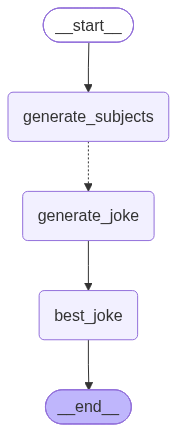

In [10]:
from IPython.display import Image

Image(app.get_graph().draw_mermaid_png())

In [12]:
for s in app.stream({"topic": "pravin"}):
    print(s)

Thread name: MainThread..inside generate_subjects
Thread name: MainThread.... continue_to_jokes
{'generate_subjects': {'subjects': ['Pravin Kumar - Indian politician', 'Pravin Gordhan - South African politician', 'Pravin Amre - Indian cricketer', 'Pravin Singh - Indian artist', 'Pravin II - an Indian historical figure']}}
Thread name: ThreadPoolExecutor-2_0.... inside generate_joke
Thread name: ThreadPoolExecutor-2_1.... inside generate_joke
Thread name: ThreadPoolExecutor-2_2.... inside generate_joke
Thread name: ThreadPoolExecutor-2_3.... inside generate_joke
Thread name: ThreadPoolExecutor-2_4.... inside generate_joke
{'generate_joke': {'jokes': ['Why did Pravin Gordhan bring a ladder to the Treasury? \n\nBecause he heard the budget was going to be "high" this year!']}}
{'generate_joke': {'jokes': ['Why did Pravin Kumar bring a ladder to the election rally?\n\nBecause he heard the votes were up for grabs!']}}
{'generate_joke': {'jokes': ['Why did Pravin Amre bring a ladder to the cr

In [13]:
for s in app.stream({"topic": "Programming"}):
    print(s)

for s in app.stream({"topic": "Food"}):
    print(s)

Thread name: MainThread..inside generate_subjects
Thread name: MainThread.... continue_to_jokes
{'generate_subjects': {'subjects': ['JavaScript', 'Python', 'Java', 'C++', 'Ruby']}}
Thread name: ThreadPoolExecutor-3_0.... inside generate_joke
Thread name: ThreadPoolExecutor-3_1.... inside generate_joke
Thread name: ThreadPoolExecutor-3_2.... inside generate_joke
Thread name: ThreadPoolExecutor-3_3.... inside generate_joke
Thread name: ThreadPoolExecutor-3_4.... inside generate_joke
{'generate_joke': {'jokes': ["Why did the JavaScript developer go broke? \n\nBecause he kept using 'null' for everything!"]}}
{'generate_joke': {'jokes': ['Why do Ruby developers prefer dark mode? \n\nBecause light attracts bugs!']}}
{'generate_joke': {'jokes': ['Why do Python programmers prefer dark mode?\n\nBecause light attracts bugs!']}}
{'generate_joke': {'jokes': ["Why do Java developers wear glasses? \n\nBecause they can't C#!"]}}
{'generate_joke': {'jokes': ['Why do programmers prefer C++ over C?\n\nB

In [15]:
class BestJoke(BaseModel):
    id: int = Field(description="Index of the best joke")


def best_joke(state: OverallState):
    thread_name = threading.current_thread().name
    print(f"Thread name: {thread_name}.... best_joke")
    jokes_numbered = "\n\n".join([f"{i+1}. {joke}" for i, joke in enumerate(state["jokes"])])
    prompt = f"""Below are a bunch of jokes about {state['topic']}. Select the best one! Return the ID of the best one.

{jokes_numbered}"""
    response = model.with_structured_output(BestJoke).invoke(prompt)
    return {"best_selected_joke": state["jokes"][response.id]}